In [1]:
import pandas as pd
from sqlalchemy import create_engine
from utils.database import get_engine
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
engine = get_engine()

df_inventory = pd.read_sql(
    "SELECT * FROM vw_inventory_health",
    engine
)

In [3]:
print(df_inventory.head())
print(df_inventory.columns)

    sku product_type  stock_levels  number_of_products_sold  \
0  SKU0     haircare            58                      802   
1  SKU1     skincare            53                      736   
2  SKU2     haircare             1                        8   
3  SKU3     skincare            23                       83   
4  SKU4     skincare             5                      871   

   inventory_turnover  
0               13.83  
1               13.89  
2                8.00  
3                3.61  
4              174.20  
Index(['sku', 'product_type', 'stock_levels', 'number_of_products_sold',
       'inventory_turnover'],
      dtype='object')


In [4]:
df_inventory["inventory_turnover"].describe()

count     99.000000
mean      28.884545
std       70.769559
min        0.260000
25%        4.570000
50%        8.690000
75%       19.975000
max      602.000000
Name: inventory_turnover, dtype: float64

In [5]:
# Top 10 Fast-Moving Products
df_inventory.sort_values(
    "inventory_turnover",
    ascending=False
).head(10)

,sku,product_type,stock_levels,number_of_products_sold,inventory_turnover
34,SKU34,skincare,1,602,602.00
47,SKU47,skincare,4,910,227.50
78,SKU78,haircare,5,946,189.20
4,SKU4,skincare,5,871,174.20
33,SKU33,cosmetics,4,616,154.00
16,SKU16,skincare,2,280,140.00
58,SKU58,skincare,10,896,89.60
44,SKU44,cosmetics,13,919,70.69
9,SKU9,skincare,14,980,70.00
18,SKU18,haircare,10,620,62.00


In [6]:
# Slow-Moving Products
df_inventory.sort_values(
    "inventory_turnover"
).head(10)

,sku,product_type,stock_levels,number_of_products_sold,inventory_turnover
45,SKU45,haircare,93,24,0.26
48,SKU48,haircare,30,29,0.97
49,SKU49,cosmetics,97,99,1.02
97,SKU97,haircare,46,62,1.35
89,SKU89,cosmetics,90,134,1.49
51,SKU51,haircare,100,154,1.54
5,SKU5,haircare,90,147,1.63
85,SKU85,cosmetics,15,25,1.67
25,SKU25,haircare,82,142,1.73
93,SKU93,haircare,63,114,1.81


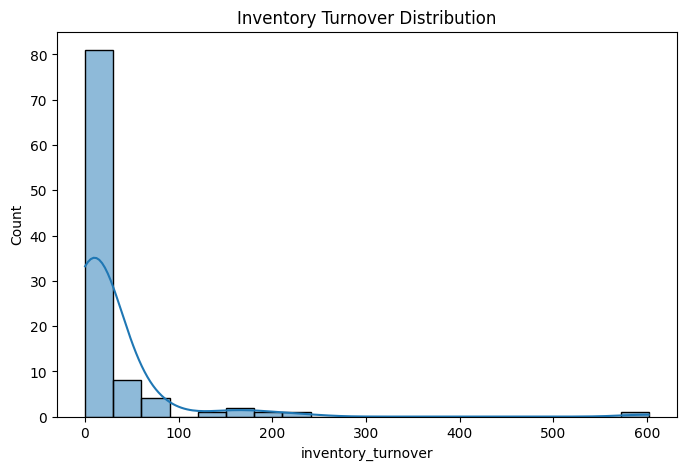

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_inventory["inventory_turnover"],
    bins=20,
    kde=True
)

plt.title("Inventory Turnover Distribution")
plt.show()

In [8]:
# Categorization based on percentiles 
def inventory_category(turnover):

    if turnover <= 4.57:
        return "Slow Moving"

    elif turnover <= 19.98:
        return "Medium Moving"

    else:
        return "Fast Moving"

df_inventory["inventory_category"] = (
    df_inventory["inventory_turnover"]
    .apply(inventory_category)
)

In [9]:
df_inventory["inventory_category"].value_counts()

inventory_category
Medium Moving    49
Fast Moving      26
Slow Moving      25
Name: count, dtype: int64

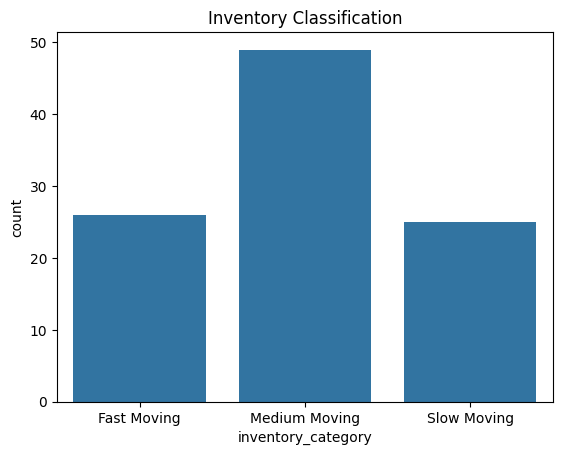

In [10]:
sns.countplot(
    data=df_inventory,
    x="inventory_category",
    order=[
        "Fast Moving",
        "Medium Moving",
        "Slow Moving"
    ]
)

plt.title("Inventory Classification")
plt.show()

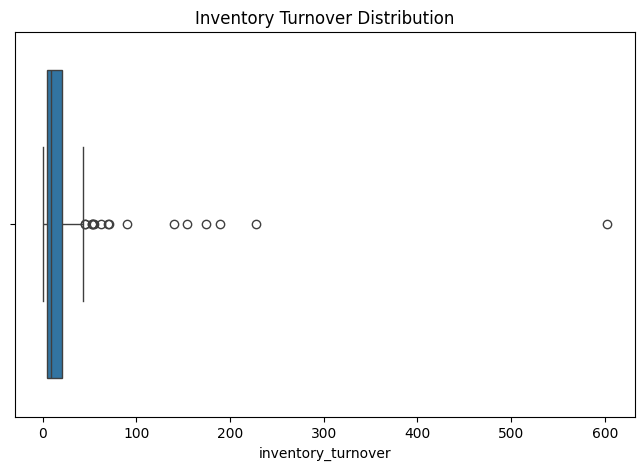

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df_inventory["inventory_turnover"]
)

plt.title("Inventory Turnover Distribution")
plt.show()

In [ ]:
## Inventory Classification Insights

Inventory turnover was classified using quartile-based thresholds derived from the dataset distribution.

### Category Distribution
- Fast Moving: 26 SKUs
- Medium Moving: 49 SKUs
- Slow Moving: 25 SKUs

### Key Findings
- Approximately one-quarter of products are fast-moving and require proactive inventory replenishment.
- Nearly half of the products fall into the medium-moving category, representing stable inventory performance.
- Twenty-five SKUs are classified as slow-moving, indicating potential overstocking or weaker demand.

### Business Implications
- Fast-moving products should be prioritized to reduce stockout risk.
- Medium-moving products can follow standard inventory management policies.
- Slow-moving products should be reviewed to optimize inventory carrying costs and improve working capital utilization.

In [12]:
Q1 = df_inventory["inventory_turnover"].quantile(0.25)
Q3 = df_inventory["inventory_turnover"].quantile(0.75)

IQR = Q3 - Q1

upper_bound = Q3 + (1.5 * IQR)

outliers = df_inventory[
    df_inventory["inventory_turnover"] > upper_bound
]

print("Number of Outliers:", len(outliers))

Number of Outliers: 16


In [13]:
outliers[
    ["sku",
     "stock_levels",
     "number_of_products_sold",
     "inventory_turnover"]
].sort_values(
    "inventory_turnover",
    ascending=False
)

,sku,stock_levels,number_of_products_sold,inventory_turnover
34,SKU34,1,602,602.00
47,SKU47,4,910,227.50
78,SKU78,5,946,189.20
4,SKU4,5,871,174.20
33,SKU33,4,616,154.00
16,SKU16,2,280,140.00
58,SKU58,10,896,89.60
44,SKU44,13,919,70.69
9,SKU9,14,980,70.00
18,SKU18,10,620,62.00


### Inventory Turnover Outlier Analysis

The inventory turnover distribution contains several high-value outliers. Further investigation showed that these products have very low stock levels combined with strong sales performance, resulting in exceptionally high turnover ratios.

These outliers are likely business-relevant observations rather than data quality issues. They may indicate high-demand products that require closer inventory monitoring and replenishment planning to reduce stockout risk.